# Workshop AI: MRI images prediction of disease status
## Msc Applied Bioinformatics, King's College London 2025-2026

## Model: Transfer learning - Resnet50V2
Disclaimer: This file contains the final version of the code. Previous experimental tests and intermediate results are not included, as the intention was to submit a clean and consolidated version of the final model design.

The training process was executed using sbatch on a GPU node due to recurring issues with the Jupyter connection, which caused the training to terminate prematurely.

The Python training script and the corresponding batch submission file are attached at the end of this document.



## 1) Experiment Design
    In each folder (category):
    - Check dimensions of images
    - Check type of data
    - Check Colours channels

In [1]:
import os
import cv2
base_path = "/cephfs/volumes/hpc_home/k25042443/ed1724b5-72a9-4c7d-aa9f-96500fb47f3d/AI_project_Tomas_PerezSanchez/data/test1"

for folder in sorted(os.listdir(base_path)):
    folder_path = os.path.join(base_path, folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                img = cv2.imread(os.path.join(folder_path, file))
                if img is not None:
                    print(f"Folder: {folder}")
                    print(f" - Dimensions: {img.shape}")
                    print(f" - type of data: {img.dtype}")
                    break 

Folder: MildImpairment
 - Dimensions: (208, 176, 3)
 - type of data: uint8
Folder: ModerateImpairment
 - Dimensions: (208, 176, 3)
 - type of data: uint8
Folder: NoImpairment
 - Dimensions: (208, 176, 3)
 - type of data: uint8


## 2) Data cleaning

### Load modules and libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score
import os
from sklearn import preprocessing 


### Counting the number of images in each file
    - Comparing frequencies and percentages via Bar-plots

MildImpairment: 1792 MRI images
ModerateImpairment: 724 MRI images
NoImpairment: 2560 MRI images


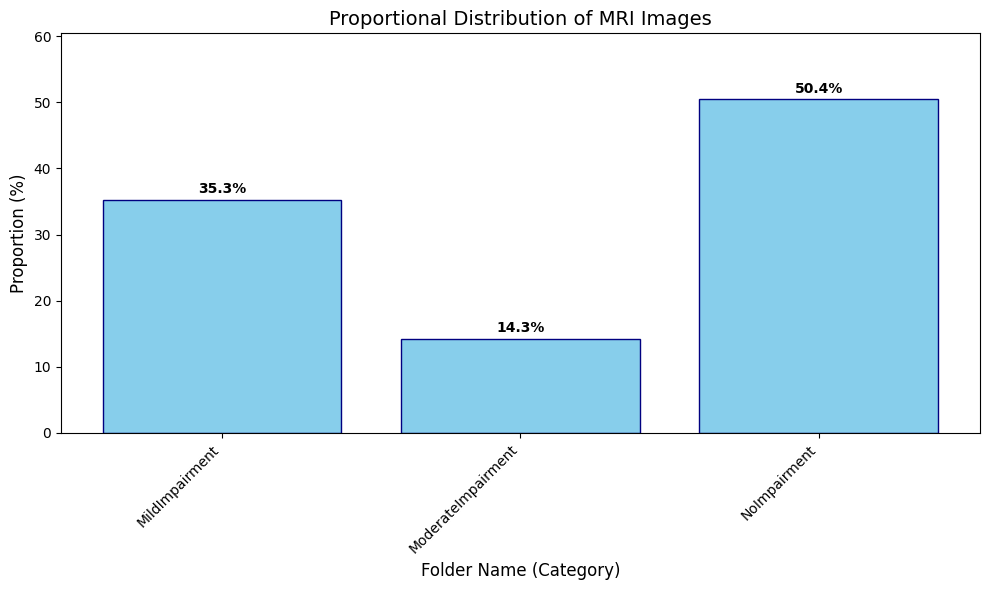

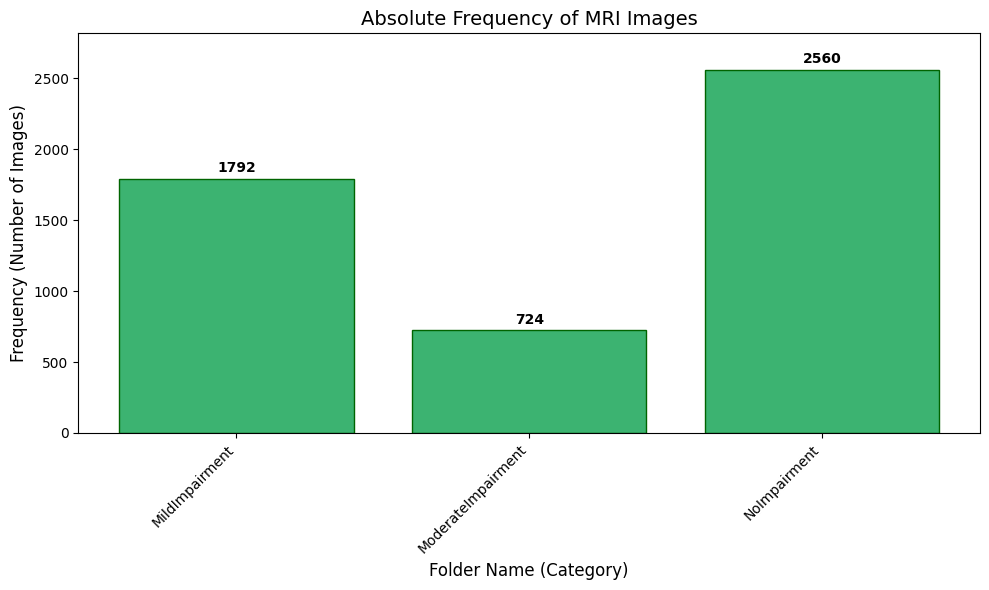


plots saved in: /cephfs/volumes/hpc_home/k25042443/ed1724b5-72a9-4c7d-aa9f-96500fb47f3d/AI_project_Tomas_PerezSanchez/results/sample_images/


In [3]:
import os
import matplotlib.pyplot as plt

# 1. Setup paths and extensions
base_path = "/cephfs/volumes/hpc_home/k25042443/ed1724b5-72a9-4c7d-aa9f-96500fb47f3d/AI_project_Tomas_PerezSanchez/data/test1"
output_path = "/cephfs/volumes/hpc_home/k25042443/ed1724b5-72a9-4c7d-aa9f-96500fb47f3d/AI_project_Tomas_PerezSanchez/results/sample_images/"
extensions = ('.png', '.jpg', '.jpeg')

if not os.path.exists(output_path):
    os.makedirs(output_path)
    print(f"new directory: {output_path}")

folder_data = {}

# 2. Collect image counts
for folder_name in sorted(os.listdir(base_path)):
    folder_path = os.path.join(base_path, folder_name)
    
    if not os.path.isdir(folder_path):
        continue

    n_images = sum(
        1 for f in os.listdir(folder_path)
        if f.lower().endswith(extensions)
    )
    
    if n_images > 0:
        folder_data[folder_name] = n_images
        print(f"{folder_name}: {n_images} MRI images")

# 3. Generate Plots
if folder_data:
    names = list(folder_data.keys())
    counts = list(folder_data.values())
    total = sum(counts)
    proportions = [(c / total) * 100 for c in counts]

    # --- PLOT 1: PROPORTIONS (%) ---
    plt.figure(figsize=(10, 6))
    bars1 = plt.bar(names, proportions, color='skyblue', edgecolor='navy')
    
    plt.xlabel('Folder Name (Category)', fontsize=12)
    plt.ylabel('Proportion (%)', fontsize=12)
    plt.title('Proportional Distribution of MRI Images', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, max(proportions) + 10)

    for bar in bars1:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    # save in the specific path
    plt.savefig(os.path.join(output_path, 'mri_proportions_chart.png'))
    plt.show()

    # --- PLOT 2: FREQUENCIES (COUNTS) ---
    plt.figure(figsize=(10, 6))
    bars2 = plt.bar(names, counts, color='mediumseagreen', edgecolor='darkgreen')

    plt.xlabel('Folder Name (Category)', fontsize=12)
    plt.ylabel('Frequency (Number of Images)', fontsize=12)
    plt.title('Absolute Frequency of MRI Images', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, max(counts) + (max(counts) * 0.1)) # Extra space for text

    for bar in bars2:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + (max(counts) * 0.01),
                 f'{int(height)}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    # save in the specific path
    plt.savefig(os.path.join(output_path, 'mri_frequencies_chart.png'))
    plt.show()
    
    print(f"\nplots saved in: {output_path}")

In [4]:
import os
base_path = "/cephfs/volumes/hpc_home/k25042443/ed1724b5-72a9-4c7d-aa9f-96500fb47f3d/AI_project_Tomas_PerezSanchez/data/test1"
extensions = ('.png', '.jpg', '.jpeg')

for folder_name in sorted(os.listdir(base_path)):
    folder_path = os.path.join(base_path, folder_name)

    
    if not os.path.isdir(folder_path):
        continue

    n_images = sum(
        1 for f in os.listdir(folder_path)
        if f.lower().endswith(extensions)
    )

    print(f"{folder_name}: {n_images} MRI images")

MildImpairment: 1792 MRI images
ModerateImpairment: 724 MRI images
NoImpairment: 2560 MRI images


### Labelling and Normalisation of each image
Expected:

- Class 0 Mild: 1792
- Class 1 Moderate: 724
- Class 2 Noimp: 2560

Normalisation: 
- Size is normalised into 224x224
- 3 channels of colour RGB, necessary for RESnet training
- data type float32 for X and int32 for Y

Contrast and segmentation of background:
- CLAHE for improving contrast, improves the learning of certain images features like texture, borders and patterns.
- OTSU is used to segment foreground and background in grayscale images. Could helps us to reduce irrelevant background information.
- Neither of them were used in the final model, because of artificial noise generation. Accuracy levels were dropping down.


In [5]:
from PIL import Image
le = preprocessing.LabelEncoder()

images = []
labels = []

for folder_name in sorted(os.listdir(base_path)):
    folder_path = os.path.join(base_path, folder_name)

    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(folder_path, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                 continue
            img = cv2.resize(img, (224, 224)) # normalise the size of the images
            #CLAHE 
            #clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            #img = clahe.apply(img)
            #OTSU
            #_, otsu_segmentation = cv2.threshold(img, 0, 255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            
            #Resnet 3 channels RGB
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) # resnet requires 3 channels, RGB.
            #img = img / 255.0 # normalise pixels values, 0-1 #test 4
            
            images.append(img)
            labels.append(folder_name)  
labels_encoded = le.fit_transform(labels) # encode our images by categories in numerical order
            
X = np.array(images,dtype=np.float32)
y = np.array(labels_encoded,dtype=np.int32)

### Normalisation check

In [6]:
print(le.classes_)
print(X.shape, y.shape)
# shape is: n of images, height, width, RGB channels
# expected: 
#['MildImpairment' 'ModerateImpairment' 'NoImpairment']
#(5076, 224, 224, 3) (5076,)

['MildImpairment' 'ModerateImpairment' 'NoImpairment']
(5076, 224, 224, 3) (5076,)


In [5]:
#check encoding process by comparing with the initial count of images
labels_encoded = np.array(labels_encoded)

print("Class 0 Mild:", np.sum(labels_encoded == 0))
print("Class 1 Moderate:", np.sum(labels_encoded == 1))
print("Class 2 Noimp:", np.sum(labels_encoded == 2))

Class 0 Mild: 1792
Class 1 Moderate: 724
Class 2 Noimp: 2560


In [13]:
print(labels[:89]) # check a random entry

['MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpairment', 'MildImpa

#### Path -> Label CHECK

In [ ]:
import os
# sanity check for path corresponds to label

extensions = ('.png', '.jpg', '.jpeg')

pairs = []
for label in sorted(os.listdir(base_path)):
    folder = os.path.join(base_path, label)
    if not os.path.isdir(folder):
        continue
    for f in os.listdir(folder):
        if f.lower().endswith(extensions):
            pairs.append((os.path.join(folder, f), label))

for p, l in pairs[1920:2000]:
    print(l, "->", p)


#### Random image visualization

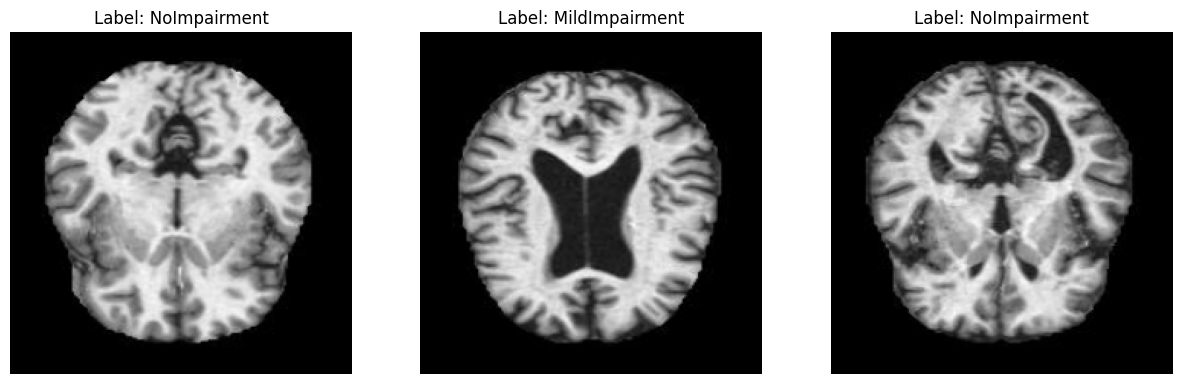

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random

# output
output_path = "/cephfs/volumes/hpc_home/k25042443/ed1724b5-72a9-4c7d-aa9f-96500fb47f3d/AI_project_Tomas_PerezSanchez/results/sample_images/"
os.makedirs(output_path, exist_ok=True)

# 1. 3 randmom images from X
n_samples = len(X)
indices = random.sample(range(n_samples), 3)

# 2. Create the figure with the 3 random images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, idx in enumerate(indices):
    
    img = X[idx]
    if img.max() > 1.0:
        img = img.astype(np.uint8)
    
    label_num = y[idx]
    label_text = le.inverse_transform([label_num])[0]
    
    axes[i].imshow(img)
    axes[i].set_title(f"Label: {label_text}")
    axes[i].axis("off")

# 3. save and show
full_save_path = os.path.join(output_path, "combined_preprocessed_samples.png")
plt.savefig(full_save_path)
plt.show()
plt.close()



In [ ]:
#random image visualisation
plt.imshow(X[808])

---

---

## Data preprocessing 

### Data split 

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-02-18 16:56:46.958801: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-18 16:56:47.535289: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-18 16:56:48.704057: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-18 16:56:54.111137: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


1) Split:
   - train 80%
   - validation 10%
   - test 10%
2) Only in train:
   - Augmentation


In [7]:
from sklearn.model_selection import train_test_split

# Step 1: separate 10% test and 80% train 
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.10,stratify=y,random_state=89)

# Step 2: finally we have 10% in validation

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,test_size=0.11111,
                                                  random_state=89,stratify=y_train)



In [8]:
print(len(X_train), len(X_val), len(X_test))
# expected 4060 508 508

4060 508 508


In [19]:
#checking distribution between classes
def show_distribution_pct(y, name):
    unique, counts = np.unique(y, return_counts=True)
    total = len(y)
    print(f"\n{name}")
    for u, c in zip(unique, counts):
        print(f"  {u}: {100*c/total:.2f}%")

show_distribution_pct(y, "TOTAL")
show_distribution_pct(y_train, "TRAIN")
show_distribution_pct(y_val, "VAL")
show_distribution_pct(y_test, "TEST")



TOTAL
  0: 35.30%
  1: 14.26%
  2: 50.43%

TRAIN
  0: 35.32%
  1: 14.24%
  2: 50.44%

VAL
  0: 35.24%
  1: 14.37%
  2: 50.39%

TEST
  0: 35.24%
  1: 14.37%
  2: 50.39%


## 3) Model selection

## Resnet50V2

In [7]:
from tensorflow.keras.applications import ResNet50V2

# We are going to use the newest version of ResNet50 Version 2
resnet_model = ResNet50V2(
    weights='imagenet',
    include_top=False,  # this removes the final classification layer of the model so we can add to it.
    input_shape= (224,224,3)
)
resnet_model.trainable = False

In [ ]:
#resnet_model.layers
#this is to see the inner layers of the model

In [9]:
# Create the preprocessing pipeline
import tensorflow as tf
from tensorflow.keras.layers import Resizing, Lambda, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications.resnet_v2 import preprocess_input
from tensorflow.keras.layers import Input, Flatten, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input, GlobalAveragePooling2D
from tensorflow.keras.layers import Flatten, Dense, Rescaling
from tensorflow.keras import layers

# the augmentation is only applied to the training set (Keras Random* layers only act in training)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomZoom(height_factor=0.05, fill_mode="constant"),
    # tf.keras.layers.RandomRotation(factor=0.03, fill_mode="constant"),
    # tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomBrightness(factor=0.05),
    tf.keras.layers.RandomContrast(factor=0.05),
], name="augmentation_layer")


n_classes = len(np.unique(y))


model = Sequential([
    tf.keras.Input(shape=(224, 224, 3)),

    data_augmentation,  # it is only applied in training

    layers.Rescaling(scale=1./127.5, offset=-1.0),

    # Backbone
    resnet_model,

    # Head
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dense(n_classes, activation="softmax"),
], name="resnet50v2_transfer_sequential")


In [11]:
import numpy as np

x0 = X_val[:1]

y1 = model(x0, training=False).numpy()
y2 = model(x0, training=False).numpy()
y3 = model(x0, training=True).numpy()
y4 = model(x0, training=True).numpy()

print("Inference equal:", np.allclose(y1, y2))
print("Training equal:", np.allclose(y3, y4))
#expected
#Inference equal: True
#Training equal: False

Inferencia igual: True
Training igual: False


### Model summary

In [10]:
from tensorflow.keras.optimizers import Adam
# Note how many parameters there are to train and how big your dataset it
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_layer (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,123,651 (92.02 MB)

 Trainable params: 558,339 (2.13 MB)

 Non-trainable params: 23,565,312 (89.89 MB)

#### Class weights
-Ponder the penalty in classes with less data.

-Adjust imbalance between classes.

In [11]:
import hashlib
import numpy as np

def hash_image(img):
    return hashlib.md5(img.tobytes()).hexdigest()
val_hashes = set(hash_image(img) for img in X_val)
test_hashes = set(hash_image(img) for img in X_test)

overlap = val_hashes.intersection(test_hashes)

print("Shared images:", len(overlap))


Imágenes compartidas: 0


In [12]:
print(np.unique(y_train))
# check our labels must be int

[0 1 2]


In [13]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)  # ej: array([0,1,2])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

class_weights = {int(c): float(w) for c, w in zip(classes, weights)}
print("classes:", classes)
print("class_weights:", class_weights)
import numpy as np

print("Train counts:", np.bincount(y_train))
print("Val counts:  ", np.bincount(y_val))
print("Test counts: ", np.bincount(y_test) if 'y_test' in globals() else "no test")



classes: [0 1 2]
class_weights: {0: 0.9437470943747094, 1: 2.3414071510957326, 2: 0.6608072916666666}
Train counts: [1434  578 2048]
Val counts:   [179  73 256]
Test counts:  [179  73 256]


In [14]:
from sklearn.utils.class_weight import compute_class_weight

# Here we use the binary(two class) cross entropy rather than categorical cross entropy since there are only two classes.
model.compile(optimizer=Adam(learning_rate= 0.0001),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
#LR 1e-4

In [15]:

model.summary() 

Entrenando para 3 clases.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_layer (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,123,651 (92.02 MB)

 Trainable params: 558,339 (2.13 MB)

 Non-trainable params: 23,565,312 (89.89 MB)

#### Training

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import tensorflow as tf
import json, os
results_dir = "/cephfs/volumes/hpc_home/k25042443/ed1724b5-72a9-4c7d-aa9f-96500fb47f3d/AI_project_Tomas_PerezSanchez/results"


checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "/cephfs/volumes/hpc_home/k25042443/ed1724b5-72a9-4c7d-aa9f-96500fb47f3d/AI_project_Tomas_PerezSanchez/results/test5.keras",
    monitor="val_loss",
    save_weights_only=False,
    save_best_only=True
) 

CF = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    checkpoint_cb
]

history_warmup = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=10,
    shuffle=True,
    validation_data=(X_val, y_val),
    callbacks=CF,
    class_weight=class_weights
)
# 5. Fine Tuning
resnet_model.trainable = True

for layer in resnet_model.layers[:-20]:
    layer.trainable = False

# Change the LR here
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 6. train again
history_finetune = model.fit(X_train, y_train, epochs=50,shuffle=True,batch_size=32, validation_data=(X_val, y_val), callbacks=CF,class_weight=class_weights) #class_weight=class_weights)

#----- SAVING DATA INTO JSON FILES
history_payload = {
    "warmup": history_warmup.history,
    "finetune": history_finetune.history
}

history_path = os.path.join(results_dir, "test5_history.json")
with open(history_path, "w") as f:
    json.dump(history_payload, f, indent=2)

warmup_epochs = list(history_warmup.epoch)
finetune_epochs = list(history_finetune.epoch)

finetune_epochs_global = [
    e + (warmup_epochs[-1] + 1) for e in finetune_epochs
]

epochs_payload = {
    "warmup": warmup_epochs,
    "finetune_global": finetune_epochs_global
}

epochs_path = os.path.join(results_dir, "test5_epochs.json")
with open(epochs_path, "w") as f:
    json.dump(epochs_payload, f, indent=2)

print("Saved history to:", history_path)
print("Saved epochs to:", epochs_path)


Epoch 1/10
 51/127 ━━━━━━━━━━━━━━━━━━━━ 1:08 904ms/step - accuracy: 0.4387 - loss: 2.8859

## Post-processing evaluation
---
---
---
    -Plot training and validation accuracy
    -Plot training and validation loss 
    -Plot confussion matrix
    -Classification report
    -ROC curves

---

---

## Final model test 

Model: "resnet50v2_transfer_sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation_layer (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,999,691 (156.40 MB)

 Trainable params: 8,438,019 (32.19 MB)

 Non-trainable params: 15,685,632 (59.84 MB)

 Optimizer params: 16,876,040 (64.38 MB)

16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 642ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 584ms/step - accuracy: 0.9219 - loss: 0.1767
Loss: 0.17633147537708282
Accuracy: 0.9370078444480896


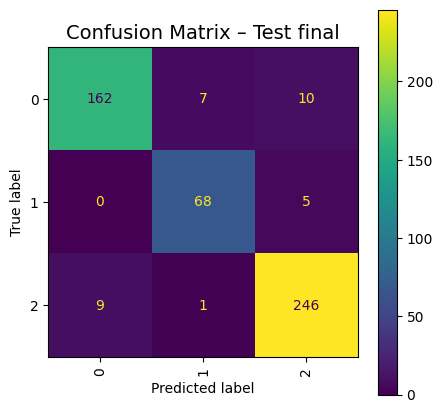

In [9]:
import keras

# Load model
model = keras.models.load_model("/cephfs/volumes/hpc_home/k25042443/ed1724b5-72a9-4c7d-aa9f-96500fb47f3d/AI_project_Tomas_PerezSanchez/results/test6.keras")

model.summary()
y_pred_probs = model.predict(X_test)
y_pred_cls = np.argmax(y_pred_probs, axis=1)
# evaluate model
results = model.evaluate(X_test, y_test, verbose=1)

print(f"Loss: {results[0]}")
print(f"Accuracy: {results[1]}")
# CONFUSSION MATRIX
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm  = confusion_matrix(y_test, y_pred_cls)
cmdisp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_title("Confusion Matrix – Test final", fontsize=14)
cmdisp.plot(include_values=True, cmap="viridis", ax=ax, xticks_rotation="vertical")
fig.savefig(
    "/cephfs/volumes/hpc_home/k25042443/ed1724b5-72a9-4c7d-aa9f-96500fb47f3d/AI_project_Tomas_PerezSanchez/results/test6_figures/confusion_matrix_test6.jpg",dpi=300,bbox_inches="tight")
plt.show()

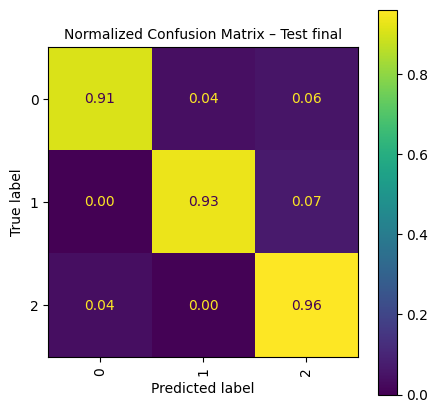

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrix normalized
cm_norm = confusion_matrix(y_test, y_pred_cls, normalize="true")

cmdisp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_title("Normalized Confusion Matrix – Test final", fontsize=10)

cmdisp.plot(
    include_values=True,
    cmap="viridis",
    ax=ax,
    xticks_rotation="vertical",
    values_format=".2f"  
)

fig.savefig(
    "/cephfs/volumes/hpc_home/k25042443/ed1724b5-72a9-4c7d-aa9f-96500fb47f3d/AI_project_Tomas_PerezSanchez/results/test6_figures/confusion_matrix_test6_normalized.jpg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [8]:
from sklearn.metrics  import classification_report
print('Classification Report:')
print(classification_report(y_test,y_pred_cls))

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       179
           1       0.89      0.93      0.91        73
           2       0.94      0.96      0.95       256

    accuracy                           0.94       508
   macro avg       0.93      0.93      0.93       508
weighted avg       0.94      0.94      0.94       508



In [11]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import classification_report, confusion_matrix

# 1. Define output files
save_path = "/cephfs/volumes/hpc_home/k25042443/ed1724b5-72a9-4c7d-aa9f-96500fb47f3d/AI_project_Tomas_PerezSanchez/results/test6_figures/"
file_name = "classification_report_extended_test6.csv"
full_file_path = os.path.join(save_path, file_name)

os.makedirs(save_path, exist_ok=True)

# 2. generate base report
report_dict = classification_report(y_test, y_pred_cls, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

# 3.rename each class with their corresponding names

new_names = {
    '0': 'Class 0 Mild',
    '1': 'Class 1 Moderate',
    '2': 'Class 2 Noimp'
}
df_report = df_report.rename(index=new_names)
df_report = df_report.rename(columns={'recall': 'sensitivity (recall)'})

cm = confusion_matrix(y_test, y_pred_cls)

# 4. Calculate specificity by class
n_classes = len(cm)
specificities = []
for i in range(n_classes):
    tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    fp = cm[:, i].sum() - cm[i, i]
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificities.append(spec)

# 5. Calculate macro and weighted average for specificity
macro_specificity = np.mean(specificities)
weights = df_report.loc[df_report.index[:n_classes], 'support']
weighted_specificity = np.average(specificities, weights=weights)

# 6. insert parameters in the data frame
spec_column = specificities + [np.nan] * (len(df_report) - n_classes)
df_report['specificity'] = spec_column
df_report.at['macro avg', 'specificity'] = macro_specificity
df_report.at['weighted avg', 'specificity'] = weighted_specificity

# re organize columns
cols = ['precision', 'sensitivity (recall)', 'specificity', 'f1-score', 'support']
df_report = df_report[cols]

# 7. round to three decimals
df_report['support'] = df_report['support'].astype(int)
df_report = df_report.round(3)

# 8. spacer
df_top = df_report.iloc[:n_classes]
df_bottom = df_report.iloc[n_classes:]
spacer = pd.DataFrame(index=[' '], columns=cols)
df_final = pd.concat([df_top, spacer, df_bottom])

# 9. export a CSV
df_final.to_csv(full_file_path, index=True)

print(f"Report saved in: {full_file_path}")
print("\nPreview of report:")
print(df_final)

Report saved in: /cephfs/volumes/hpc_home/k25042443/ed1724b5-72a9-4c7d-aa9f-96500fb47f3d/AI_project_Tomas_PerezSanchez/results/test6_figures/classification_report_extended_test6.csv

Preview of report:
                  precision  sensitivity (recall)  specificity  f1-score  \
Class 0 Mild          0.947                 0.905        0.973     0.926   
Class 1 Moderate      0.895                 0.932        0.982     0.913   
Class 2 Noimp         0.943                 0.961        0.940     0.952   
                        NaN                   NaN          NaN       NaN   
accuracy              0.937                 0.937          NaN     0.937   
macro avg             0.928                 0.932        0.965     0.930   
weighted avg          0.937                 0.937        0.958     0.937   

                 support  
Class 0 Mild         179  
Class 1 Moderate      73  
Class 2 Noimp        256  
                     NaN  
accuracy               0  
macro avg            508  


/tmp/ipykernel_3326533/2747891523.py:61: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_final = pd.concat([df_top, spacer, df_bottom])


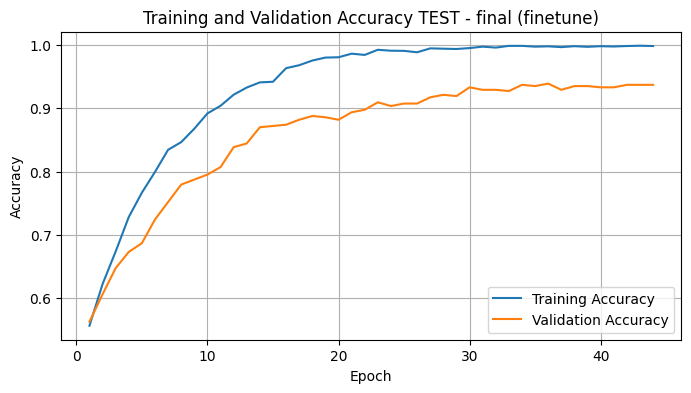

In [12]:
import json
import matplotlib.pyplot as plt

with open('/cephfs/volumes/hpc_home/k25042443/ed1724b5-72a9-4c7d-aa9f-96500fb47f3d/AI_project_Tomas_PerezSanchez/results/test6history.json', 'r') as f:
    history = json.load(f)

acc = history['finetune']['accuracy']
val_acc = history['finetune']['val_accuracy']

epochs = list(range(1, len(acc) + 1))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs, acc, label='Training Accuracy')
ax.plot(epochs, val_acc, label='Validation Accuracy')
ax.set_title('Training and Validation Accuracy TEST - final (finetune)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True)

fig.savefig(
    "/cephfs/volumes/hpc_home/k25042443/ed1724b5-72a9-4c7d-aa9f-96500fb47f3d/AI_project_Tomas_PerezSanchez/results/test6_figures/training_and_ValidationACCURACY_test6.jpg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


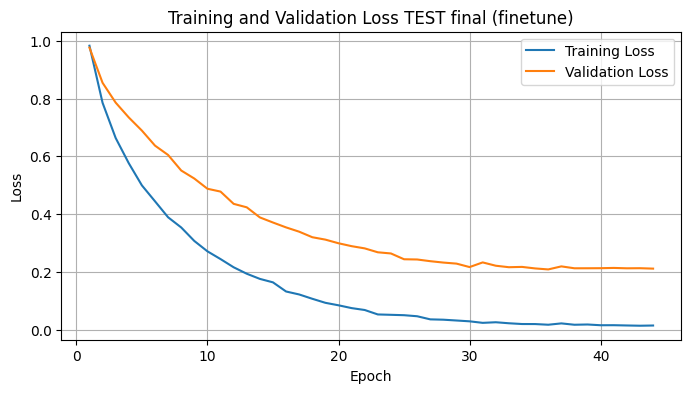

In [15]:
import json
import matplotlib.pyplot as plt

# 1. Load history json
with open('/cephfs/volumes/hpc_home/k25042443/ed1724b5-72a9-4c7d-aa9f-96500fb47f3d/AI_project_Tomas_PerezSanchez/results/test6history.json', 'r') as f:
    history_data_test6 = json.load(f)

# 2. Extract finetune loss values
loss_values = history_data_test6['finetune']['loss']
val_loss_values = history_data_test6['finetune']['val_loss']

# 3. Create epoch axis automatically
epochs = list(range(1, len(loss_values) + 1))

# 4. Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs, loss_values, label='Training Loss')
ax.plot(epochs, val_loss_values, label='Validation Loss')

ax.set_title('Training and Validation Loss TEST final (finetune)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)

# 5. Save figure
fig.savefig(
    "/cephfs/volumes/hpc_home/k25042443/ed1724b5-72a9-4c7d-aa9f-96500fb47f3d/AI_project_Tomas_PerezSanchez/results/test6_figures/Training_and_Validation_testfinal.jpg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


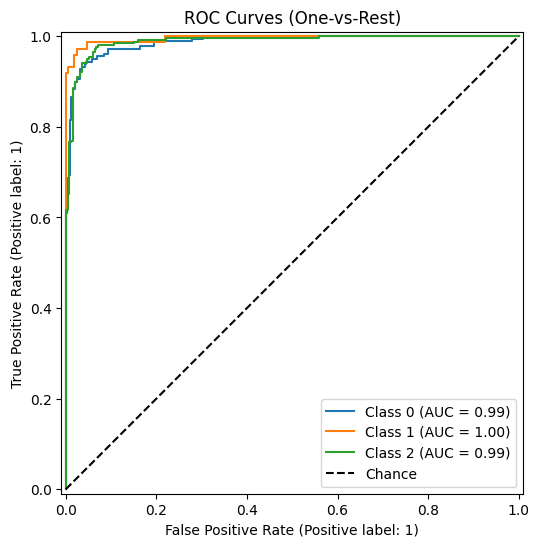

In [12]:
from sklearn.preprocessing import label_binarize
import numpy as np

n_classes = y_pred_probs.shape[1]
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

for i in range(n_classes):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        y_pred_probs[:, i],
        name=f"Class {i}",
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend()
plt.show()



# Python script used in sbatch to run training

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score

import os
from sklearn import preprocessing 
import cv2
import os
base_path = "/cephfs/volumes/hpc_home/k25042443/ed1724b5-72a9-4c7d-aa9f-96500fb47f3d/AI_project_Tomas_PerezSanchez/data/test1"
extensions = ('.png', '.jpg', '.jpeg')

for folder_name in sorted(os.listdir(base_path)):
    folder_path = os.path.join(base_path, folder_name)

    if not os.path.isdir(folder_path):
        continue

    n_images = sum(
        1 for f in os.listdir(folder_path)
        if f.lower().endswith(extensions)
    )

    print(f"{folder_name}: {n_images} MRI images")
from PIL import Image
le = preprocessing.LabelEncoder()

images = []
labels = []

for folder_name in sorted(os.listdir(base_path)):
    folder_path = os.path.join(base_path, folder_name)

    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(folder_path, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                 continue
            img = cv2.resize(img, (224, 224)) # normalise the size of the images
            #CLAHE comment for test 1
            #clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            #img = clahe.apply(img)
            #OTSU comment for test 1
            #_, otsu_segmentation = cv2.threshold(img, 0, 255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            #Resnet 3 channels RGB
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) # resnet requires 3 channels, RGB.
            #img = img / 255.0 # normalise pixels values, 0-1
            
            images.append(img)
            labels.append(folder_name)  
labels_encoded = le.fit_transform(labels) # encode our images by categories in numerical order
            
X = np.array(images,dtype=np.float32)
y = np.array(labels_encoded,dtype=np.int32)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# Step 1: separate 10% test and 80% train 
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.10,stratify=y,random_state=89)

# Step 2: finally we have 10% in validation

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,test_size=0.1111,random_state=89,stratify=y_train)

# make sure they are float32
#X_train = X_train.astype(np.float32)
#X_val   = X_val.astype(np.float32)
#X_test  = X_test.astype(np.float32)
from tensorflow.keras.applications import ResNet50V2

# We are going to use the newest version of ResNet50 Version 2
resnet_model = ResNet50V2(
    weights='imagenet',
    include_top=False,  # this removes the final classification layer of the model so we can add to it.
    input_shape= (224,224,3)
)
resnet_model.trainable = False
###
###
# Create the preprocessing pipeline
import tensorflow as tf
from tensorflow.keras.layers import Resizing, Lambda, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications.resnet_v2 import preprocess_input
from tensorflow.keras.layers import Input, Flatten, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input, GlobalAveragePooling2D
from tensorflow.keras.layers import Flatten, Dense, Rescaling
from tensorflow.keras import layers

# the augmentation is only applied to the training set (Keras Random* layers only act in training)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomZoom(height_factor=0.05, fill_mode="constant"),
    # tf.keras.layers.RandomRotation(factor=0.03, fill_mode="constant"),
    # tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomBrightness(factor=0.05),
    tf.keras.layers.RandomContrast(factor=0.05),
], name="augmentation_layer")

n_classes = len(np.unique(y))


model = Sequential([
    tf.keras.Input(shape=(224, 224, 3)),

    data_augmentation,  # only in training

    
    layers.Rescaling(scale=1./127.5, offset=-1.0),

    # Backbone
    resnet_model,

    # Head
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dense(n_classes, activation="softmax"),
], name="resnet50v2_transfer_sequential")

model.summary()




###
###
###

from tensorflow.keras.optimizers import Adam
# Note how many parameters there are to train and how big your dataset it
model.summary()

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)  # ej: array([0,1,2])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

class_weights = {int(c): float(w) for c, w in zip(classes, weights)}
print("classes:", classes)
print("class_weights:", class_weights)
import numpy as np

print("Train counts:", np.bincount(y_train))
print("Val counts:  ", np.bincount(y_val))
print("Test counts: ", np.bincount(y_test) if 'y_test' in globals() else "no test")

from sklearn.utils.class_weight import compute_class_weight

# Here we use the binary(two class) cross entropy rather than categorical cross entropy since there are only two classes.
model.compile(optimizer=Adam(learning_rate= 0.0001),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import tensorflow as tf
import json, os
results_dir = "/cephfs/volumes/hpc_home/k25042443/ed1724b5-72a9-4c7d-aa9f-96500fb47f3d/AI_project_Tomas_PerezSanchez/results"


checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "/cephfs/volumes/hpc_home/k25042443/ed1724b5-72a9-4c7d-aa9f-96500fb47f3d/AI_project_Tomas_PerezSanchez/results/test6.keras",
    monitor="val_loss",
    save_weights_only=False,
    save_best_only=True
) # load best model

CF = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    checkpoint_cb
]

history_warmup = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=10,
    shuffle=True,
    validation_data=(X_val, y_val),
    callbacks=CF,
    class_weight=class_weights
)
# 5. Fine Tuning
resnet_model.trainable = True

for layer in resnet_model.layers[:-20]:
    layer.trainable = False


model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 6. train again
history_finetune = model.fit(X_train, y_train, epochs=50,shuffle=True,batch_size=32, validation_data=(X_val, y_val), callbacks=CF,class_weight=class_weights) #class_weight=class_weights)

#----- SAVING DATA INTO JSON FILES
history_payload = {
    "warmup": history_warmup.history,
    "finetune": history_finetune.history
}

history_path = os.path.join(results_dir, "test6history.json")
with open(history_path, "w") as f:
    json.dump(history_payload, f, indent=2)

warmup_epochs = list(history_warmup.epoch)
finetune_epochs = list(history_finetune.epoch)

finetune_epochs_global = [
    e + (warmup_epochs[-1] + 1) for e in finetune_epochs
]

epochs_payload = {
    "warmup": warmup_epochs,
    "finetune_global": finetune_epochs_global
}

epochs_path = os.path.join(results_dir, "test6epochs.json")
with open(epochs_path, "w") as f:
    json.dump(epochs_payload, f, indent=2)

print("Saved history to:", history_path)
print("Saved epochs to:", epochs_path)


### Batch file

In [ ]:
#!/bin/bash
#SBATCH --job-name=test6_resnet
#SBATCH --output=/cephfs/volumes/hpc_home/k25042443/ed1724b5-72a9-4c7d-aa9f-96500fb47f3d/AI_project_Tomas_PerezSanchez/logs/test6_%j.out
#SBATCH --error=/cephfs/volumes/hpc_home/k25042443/ed1724b5-72a9-4c7d-aa9f-96500fb47f3d/AI_project_Tomas_PerezSanchez/logs/test6_%j.err
#SBATCH --time=05:00:00
#SBATCH --mem=32G
#SBATCH --cpus-per-task=8
#SBATCH --gres=gpu:1
#SBATCH --partition=interruptible_gpu

# 1. go the path of the code
cd /cephfs/volumes/hpc_home/k25042443/ed1724b5-72a9-4c7d-aa9f-96500fb47f3d/AI_project_Tomas_PerezSanchez/code

# 2. Activate virtual environment 
source /users/k25042443/AI_project_Tomas_PerezSanchez/code/juliancasablancas/bin/activate

# 3. check gpu
echo "--- Checking state of gpu ---"
nvidia-smi || true

# 4. execute python file
echo "--- starting---"
python -u test6.py